In [1]:
import HPLC

chrom = HPLC.load("./data/EGG_HILIC_GlcNAc_0.2mM_20ul_80%MeCN_pH3_20mM_NH4OHC13.03.2026 17-17-16.dat")
chrom.display()
chrom = chrom.identify_peaks()

chrom.list_peaks()

pNPS = HPLC.compound(rt = 3.5, spread = 0.1, rf = 1000)
pNP = HPLC.compound(rt = 0.3, spread = 0.1, rf = lambda area: 10000 * area ** 2)

GlcNAc_part_1 = HPLC.compound(rt = 3.76, spread = 0.1, rf = lambda area: 5600 * area ** 2)
GlcNAc_part_2 = HPLC.compound(rt = 4.34, spread = 0.1, rf = lambda area: 3400 * area ** 2)
GlcNAc = HPLC.compounds.composite([GlcNAc_part_1,GlcNAc_part_2])

chrom = chrom.associate_compounds([pNPS,pNP, GlcNAc]).display()
chrom.display_publication_graph(filename = "publication_chromatogram.png")

ModuleNotFoundError: No module named 'HPLC'

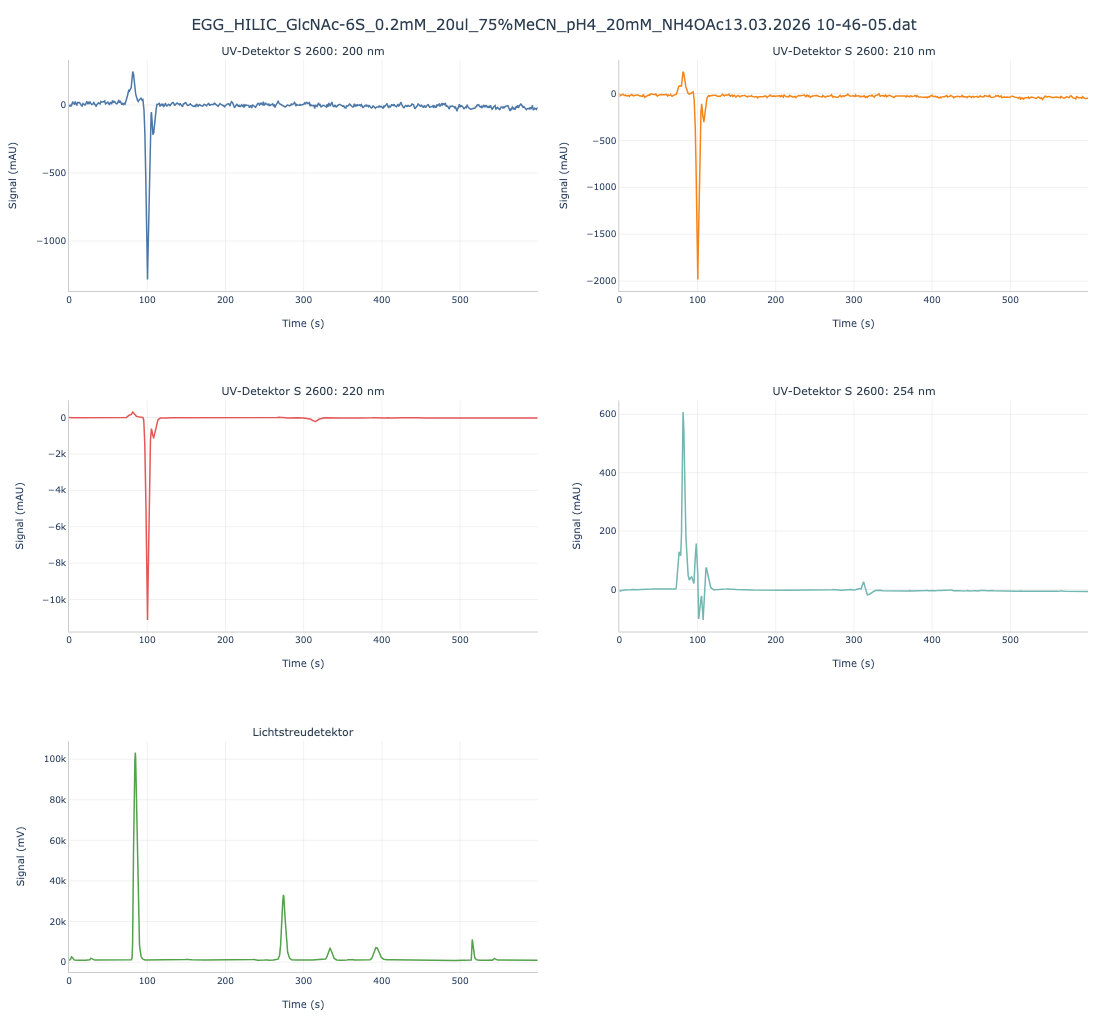

In [2]:
import HPLC
import numpy as np

HPLC.load("./data/EGG_HILIC_GlcNAc-6S_0.2mM_20ul_75%MeCN_pH4_20mM_NH4OAc13.03.2026 10-46-05.dat").display()

In [32]:
def make_signal_with_peaks(peaks, duration=900, dt=1, noise_scale=2, seed=42):
    """
    peaks: list of dicts, each with:
        - center: float (seconds)
        - height: float (mAU)
        - half_life: float (seconds)
        - front_skew: float (1.0 = no skew, <1 = sharper front, >1 = stretched front)
        - tail_skew: float (1.0 = no skew, <1 = sharper tail, >1 = stretched tail)
    """
    rng = np.random.default_rng(seed)
    time = np.arange(0, duration, dt, dtype=float)
    signal = rng.normal(loc=0, scale=noise_scale, size=len(time))

    for p in peaks:
        sigma_base = p["half_life"] / np.sqrt(2 * np.log(2))
        sigma_front = sigma_base * p.get("front_skew", 1.0)
        sigma_tail = sigma_base * p.get("tail_skew", 1.0)

        left = np.exp(-0.5 * ((time - p["center"]) / sigma_front) ** 2)
        right = np.exp(-0.5 * ((time - p["center"]) / sigma_tail) ** 2)

        peak = p["height"] * np.where(time <= p["center"], left, right)
        signal += peak

    return HPLC.Signal2D(
        detector_name="UV-Detektor S 2600: 254 nm",
        time=time,
        time_unit="s",
        signal=signal,
        signal_unit="mAU",
    )


def expected_peak_properties(peaks, n_sigma=3.0):
    """
    Given the same peak dicts passed to make_signal_with_peaks,
    returns a list of dicts with: center, height, start, end, area.

    n_sigma: how many base sigmas out to define start/end (4.0 captures ~99.99%)
    """
    results = []
    for p in peaks:
        sigma_base = p["half_life"] / np.sqrt(2 * np.log(2))
        sigma_front = sigma_base * p.get("front_skew", 1.0)
        sigma_tail = sigma_base * p.get("tail_skew", 1.0)

        start = p["center"] - n_sigma * sigma_front
        end = p["center"] + n_sigma * sigma_tail

        # Area of a split Gaussian: half-Gaussian left + half-Gaussian right
        area = p["height"] * np.sqrt(2 * np.pi) * (sigma_front + sigma_tail) / 2

        results.append({
            "center": p["center"],
            "height": p["height"],
            "start": start,
            "end": end,
            "area": area,
            "sigma_front": sigma_front,
            "sigma_tail": sigma_tail,
        })
    return results

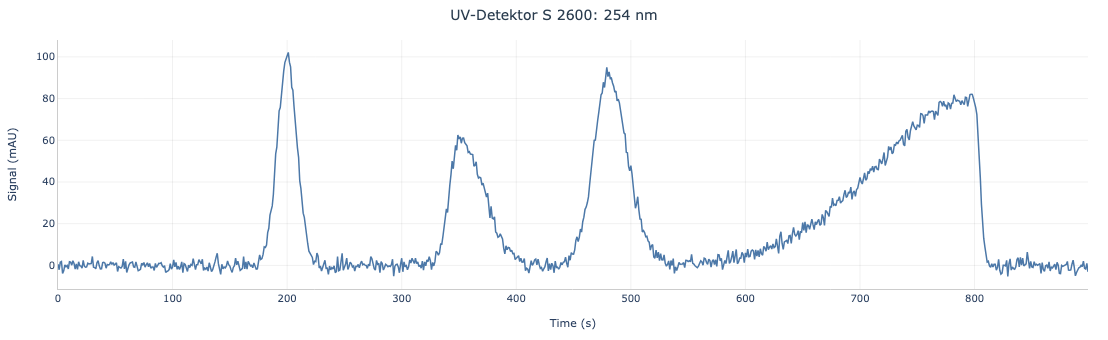

[{'center': 800,
  'height': 80,
  'start': np.float64(545.2034599135943),
  'end': np.float64(812.7398270043203),
  'area': np.float64(8941.522963222298),
  'sigma_front': np.float64(84.93218002880191),
  'sigma_tail': np.float64(4.2466090014400955)},
 {'center': 200,
  'height': 100,
  'start': np.float64(174.52034599135942),
  'end': np.float64(225.47965400864058),
  'area': np.float64(2128.9340388624523),
  'sigma_front': np.float64(8.493218002880191),
  'sigma_tail': np.float64(8.493218002880191)},
 {'center': 350,
  'height': 60,
  'start': np.float64(324.5203459913594),
  'end': np.float64(413.6991350216014),
  'area': np.float64(2235.380740805575),
  'sigma_front': np.float64(8.493218002880191),
  'sigma_tail': np.float64(21.233045007200477)},
 {'center': 480,
  'height': 90,
  'start': np.float64(441.78051898703916),
  'end': np.float64(530.9593080172812),
  'area': np.float64(3353.0711112083623),
  'sigma_front': np.float64(12.739827004320286),
  'sigma_tail': np.float64(16.9

In [33]:
signal = make_signal_with_peaks([
    {"center": 800, "height": 80,  "half_life": 5, "front_skew": 20.0, "tail_skew": 1.0},   # fronting
    {"center": 200, "height": 100, "half_life": 10, "front_skew": 1.0, "tail_skew": 1.0},   # symmetric
    {"center": 350, "height": 60,  "half_life": 10, "front_skew": 1.0, "tail_skew": 2.5},   # tailing
    {"center": 480, "height": 90,  "half_life": 10, "front_skew": 1.5, "tail_skew": 2.0},   # both
]).display()

expected = expected_peak_properties([
    {"center": 800, "height": 80,  "half_life": 5, "front_skew": 20.0, "tail_skew": 1.0},   # fronting
    {"center": 200, "height": 100, "half_life": 10, "front_skew": 1.0, "tail_skew": 1.0},   # symmetric
    {"center": 350, "height": 60,  "half_life": 10, "front_skew": 1.0, "tail_skew": 2.5},   # tailing
    {"center": 480, "height": 90,  "half_life": 10, "front_skew": 1.5, "tail_skew": 2.0},   # both
])

expected